O dataset utilizado é proveniente da plataforma Kaggle e representa o histórico de incidentes/tickets (aprox. 100k registros), contendo atributos operacionais do ticket, como categoria, CI, WBS, prioridade, relacionamentos com interações e incidentes, além de informações temporais (horários).  

O objetivo do trabalho é apoiar a melhoria da gestão de incidentes no contexto de boas práticas **ITIL**, uma vez que os resultados das avaliações/surveys indicam um atendimento considerado fraco; diante disso, a gestão pretende explorar técnicas de Machine Learning para viabilizar **previsão** (ex.: risco de insatisfação) e iniciativas de **automação** no processo de tratamento e priorização de incidentes.

In [ ]:
# Parte 1 — Aquisição e Exploração (ITSM_Dataset.csv)
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np


path = "ITSM_Dataset.csv"

df = pd.read_csv(path, sep=";", encoding="utf-8")  # sep=";" porque o ficheiro vem separado por ;

# Mostrar primeiras linhas
display(df.head())

# Estrutura e tipos
df.info()  # resumo: colunas, não-nulos, dtypes, memória

# Estatística descritiva (inclui categóricas com include="all")
display(df.describe(include="all")) 

#fds

,Status,Ticket ID,Priority,Source,Topic,Agent Group,Agent Name,Created time,Expected SLA to resolve,Expected SLA to first response,...,Resolution time,SLA For Resolution,Close time,Agent interactions,Survey results,Product group,Support Level,Country,Latitude,Longitude
0,Closed,TCKT-100000,High,Email,General Inquiry,Security,Khalid Al-Salem,04/07/2024 12:42,04/07/2024 14:42,04/07/2024 13:12,...,04/07/2024 14:30,Met,04/07/2024 14:32,5,Neutral,Cloud,L3,Oman,25.1856,50.9447
1,Closed,TCKT-100001,High,Chat,Network Issue,Customer Service,Ahmed Al-Sabah,23/05/2024 20:03,23/05/2024 22:03,23/05/2024 20:33,...,23/05/2024 22:00,Met,23/05/2024 22:05,4,Dissatisfied,Cloud,L2,Qatar,23.2741,55.3867
2,In Progress,TCKT-100002,Low,Phone,General Inquiry,Development,Mohammed Al-Mansoori,13/04/2024 20:51,14/04/2024 00:51,13/04/2024 21:51,...,14/04/2024 00:47,Met,14/04/2024 00:51,3,Dissatisfied,Software,L1,Bahrain,23.6264,50.1302
3,Resolved,TCKT-100003,Critical,Chat,Access Request,Development,Mohammed Al-Khalifa,13/05/2024 12:50,13/05/2024 13:50,13/05/2024 13:00,...,13/05/2024 13:48,Met,13/05/2024 13:53,5,Dissatisfied,Network,L2,Kuwait,25.0736,54.8437
4,Closed,TCKT-100004,Critical,Portal,Hardware Failure,Customer Service,Hassan Al-Nasser,19/06/2024 22:51,19/06/2024 23:51,19/06/2024 23:01,...,19/06/2024 23:49,Met,19/06/2024 23:54,4,Neutral,Hardware,L3,Qatar,24.7362,51.4839


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Status                          100000 non-null  str    
 1   Ticket ID                       100000 non-null  str    
 2   Priority                        100000 non-null  str    
 3   Source                          100000 non-null  str    
 4   Topic                           100000 non-null  str    
 5   Agent Group                     100000 non-null  str    
 6   Agent Name                      100000 non-null  str    
 7   Created time                    100000 non-null  str    
 8   Expected SLA to resolve         100000 non-null  str    
 9   Expected SLA to first response  100000 non-null  str    
 10  First response time             100000 non-null  str    
 11  SLA For first response          100000 non-null  str    
 12  Resolution time             

,Status,Ticket ID,Priority,Source,Topic,Agent Group,Agent Name,Created time,Expected SLA to resolve,Expected SLA to first response,...,Resolution time,SLA For Resolution,Close time,Agent interactions,Survey results,Product group,Support Level,Country,Latitude,Longitude
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,...,100000,100000,100000,100000.000000,100000,100000,100000,100000,100000.000000,100000.000000
unique,5,100000,4,4,5,5,80,77910,77840,78000,...,78103,1,77880,NaN,3,4,3,6,NaN,NaN
top,Resolved,TCKT-100000,Medium,Chat,General Inquiry,Development,Mohammed Al-Hamdan,19/04/2024 06:10,21/06/2024 22:27,09/06/2024 23:36,...,29/07/2024 04:33,Met,06/08/2024 18:58,NaN,Dissatisfied,Hardware,L3,Qatar,NaN,NaN
freq,20134,1,25117,25140,20254,20158,1491,6,6,6,...,6,100000,6,NaN,33409,25087,33344,17005,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.003470,NaN,NaN,NaN,NaN,24.002431,53.004252
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.415612,NaN,NaN,NaN,NaN,1.156356,1.729986
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,22.000000,50.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,22.998075,51.502675
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,24.007500,53.005550
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,25.000725,54.504500


In [2]:
# Converter as colunas de tempo


date_cols = [
    "Created time",
    "Expected SLA to resolve",
    "Expected SLA to first response",
    "First response time",
    "Resolution time",
    "Close time",
]

for c in date_cols:
    df[c] = pd.to_datetime(df[c], dayfirst=True, errors="coerce")  

# Ver quantos ficaram NaT (datas que não converteram)
print(df[date_cols].isna().sum().sort_values(ascending=False))
print(df[date_cols].dtypes)



Created time                      0
Expected SLA to resolve           0
Expected SLA to first response    0
First response time               0
Resolution time                   0
Close time                        0
dtype: int64
Created time                      datetime64[us]
Expected SLA to resolve           datetime64[us]
Expected SLA to first response    datetime64[us]
First response time               datetime64[us]
Resolution time                   datetime64[us]
Close time                        datetime64[us]
dtype: object


In [3]:
# Converter colunas de data para datetime
date_cols = [
    "Created time",
    "Expected SLA to resolve",
    "Expected SLA to first response",
    "First response time",
    "Resolution time",
    "Close time",
]

for c in date_cols:
    df[c] = pd.to_datetime(df[c], dayfirst=True, errors="coerce")  # 

df[date_cols].info()


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   Created time                    100000 non-null  datetime64[us]
 1   Expected SLA to resolve         100000 non-null  datetime64[us]
 2   Expected SLA to first response  100000 non-null  datetime64[us]
 3   First response time             100000 non-null  datetime64[us]
 4   Resolution time                 100000 non-null  datetime64[us]
 5   Close time                      100000 non-null  datetime64[us]
dtypes: datetime64[us](6)
memory usage: 4.6 MB


In [4]:
df[date_cols].isna().sum().sort_values(ascending=False)


Created time                      0
Expected SLA to resolve           0
Expected SLA to first response    0
First response time               0
Resolution time                   0
Close time                        0
dtype: int64

respostas Parte 1
Quantas linhas e colunas tem?
O dataset tem 100000 linhas e 22 colunas (shape = (100000, 22)).

Que tipos de variáveis existem (numéricas, categóricas, datas)?

Numéricas: Agent interactions (int), Latitude e Longitude (float).

Categóricas/texto: Status, Ticket ID, Priority, Source, Topic, Agent Group, Agent Name, SLA For first response, SLA For Resolution, 
Survey results, Product group, Support Level, Country.

Qual é a pergunta principal que queres responder com estes dados?
A pergunta principal que eu quero responder com estes dados é: “A satisfação do utilizador (Survey results) depende do desempenho de SLA (tempo de primeira resposta e tempo de resolução) e quais categorias/agentes têm melhores e piores avaliações?”



In [5]:
df = df.drop(columns=["Ticket ID", "Latitude", "Longitude"], errors="ignore")
print(df.shape)

#Remover colunas pouco úteis
#Ticket ID é identificador; Latitude/Longitude normalmente não ajudam para SLA/survey


(100000, 19)


In [6]:
# Calcular tempos e SLA
df["First response minutes"] = (df["First response time"] - df["Created time"]).dt.total_seconds()/60
df["Time to resolve minutes"] = (df["Resolution time"] - df["Created time"]).dt.total_seconds()/60
df["Time to close minutes"] = (df["Close time"] - df["Created time"]).dt.total_seconds()/60


In [7]:
#Remover colunas que não ajudam no modelo
cols_drop = ["Ticket ID", "Latitude", "Longitude"]
df = df.drop(columns=cols_drop, errors="ignore")  


In [8]:
# 3) Inspeção rápida (avaliar o dataset)
print("Shape:", df.shape)
print("\nTipos de dados:")
print(df.dtypes)

print("\nMissing values por coluna (top 15):")
print(df.isna().sum().sort_values(ascending=False).head(15))

print("\nPrimeiras linhas:")
print(df.head())

Shape: (100000, 22)

Tipos de dados:
Status                                       str
Priority                                     str
Source                                       str
Topic                                        str
Agent Group                                  str
Agent Name                                   str
Created time                      datetime64[us]
Expected SLA to resolve           datetime64[us]
Expected SLA to first response    datetime64[us]
First response time               datetime64[us]
SLA For first response                       str
Resolution time                   datetime64[us]
SLA For Resolution                           str
Close time                        datetime64[us]
Agent interactions                         int64
Survey results                               str
Product group                                str
Support Level                                str
Country                                      str
First response minutes          

In [9]:
# Normalizar strings evita “ Positive ” vs “Positive”
obj_cols = df.select_dtypes(include=["object", "string"]).columns
df[obj_cols] = df[obj_cols].apply(lambda s: s.astype("string").str.strip())



In [10]:

# Checks de consistência (quantos casos "impossíveis")
bad = pd.DataFrame({
    "fr_negative": df["First response minutes"] < 0,
    "res_negative": df["Time to resolve minutes"] < 0,
    "close_negative": df["Time to close minutes"] < 0,
})
print(bad.sum())


fr_negative       0
res_negative      0
close_negative    0
dtype: int64


In [11]:
#Duplicados 
before = len(df)
df = df.drop_duplicates()  
print("Duplicados removidos:", before - len(df))
print("Shape agora:", df.shape)


Duplicados removidos: 0
Shape agora: (100000, 22)


In [12]:
# Sumário de quantis dos tempos (ajusta se ainda não tiveres as colunas)
q = df[["First response minutes", "Time to resolve minutes", "Time to close minutes"]].quantile(
    [0.5, 0.9, 0.95, 0.99]
) 
display(q)

# Exemplo simples: cap no p99 (winsorization leve)
cap_fr = df["First response minutes"].quantile(0.99)
cap_res = df["Time to resolve minutes"].quantile(0.99)

df["First response minutes_capped"] = df["First response minutes"].clip(upper=cap_fr)
df["Time to resolve minutes_capped"] = df["Time to resolve minutes"].clip(upper=cap_res)


,First response minutes,Time to resolve minutes,Time to close minutes
0.50,35.0,160.0,160.0
0.90,56.0,232.0,235.0
0.95,58.0,236.0,239.0
0.99,60.0,240.0,243.0


In [13]:
# Definir nova coluna 
df["Time to resolve minutes"] = (
    (df["Resolution time"] - df["Created time"]).dt.total_seconds() / 60
)

df["Resolution SLA slack (min)"] = (
    (df["Expected SLA to resolve"] - df["Created time"]).dt.total_seconds()/60
    - df["Time to resolve minutes"]
)
df["Resolve time band"] = pd.cut(
    df["Time to resolve minutes"],
    bins=[-0.1, 60, 240, 1440, float("inf")],
    labels=["<=1h", "1-4h", "4-24h", ">24h"],
    include_lowest=True
)



O que concluir Parte 2 – Outliers

Analisei outliers nas variáveis de tempo usando quantis (p50/p90/p95/p99).
​

Os valores são bastante estáveis: p99 ≈ 60 min (first response) e p99 ≈ 240 min (resolução), indicando baixa presença de outliers extremos.
​

Por isso, optei por não remover registos; no máximo apliquei capping no p99 para robustez em modelos/plots.

In [14]:
df["Created_hour"] = df["Created time"].dt.hour        # 0–23
df["Created_dow"] = df["Created time"].dt.dayofweek    # 0=Seg ... 
df["Created_month"] = df["Created time"].dt.month      # 1–12



In [15]:
cols_drop_part3 = ["Status", "Agent Name", "Time to close minutes"]

df3 = df.drop(columns=cols_drop_part3, errors="ignore")  
print("Antes:", df.shape)
print("Depois:", df3.shape)
print("Removidas (se existiam):", cols_drop_part3)



Antes: (100000, 29)
Depois: (100000, 26)
Removidas (se existiam): ['Status', 'Agent Name', 'Time to close minutes']


In [16]:
print(list(df3.columns))


['Priority', 'Source', 'Topic', 'Agent Group', 'Created time', 'Expected SLA to resolve', 'Expected SLA to first response', 'First response time', 'SLA For first response', 'Resolution time', 'SLA For Resolution', 'Close time', 'Agent interactions', 'Survey results', 'Product group', 'Support Level', 'Country', 'First response minutes', 'Time to resolve minutes', 'First response minutes_capped', 'Time to resolve minutes_capped', 'Resolution SLA slack (min)', 'Resolve time band', 'Created_hour', 'Created_dow', 'Created_month']


Parte 3 — Análise e Visualização 

Pergunta 1 (Distribuição)
Como se distribui o tempo de resolução


In [17]:
df3["Time to resolve minutes_capped"].value_counts().head(20)


Time to resolve minutes_capped
58.0     1305
173.0    1282
106.0    1277
177.0    1273
225.0    1262
116.0    1251
176.0    1248
111.0    1241
47.0     1239
53.0     1238
113.0    1228
179.0    1226
220.0    1224
166.0    1222
41.0     1217
49.0     1214
222.0    1214
110.0    1213
232.0    1212
161.0    1212
Name: count, dtype: int64

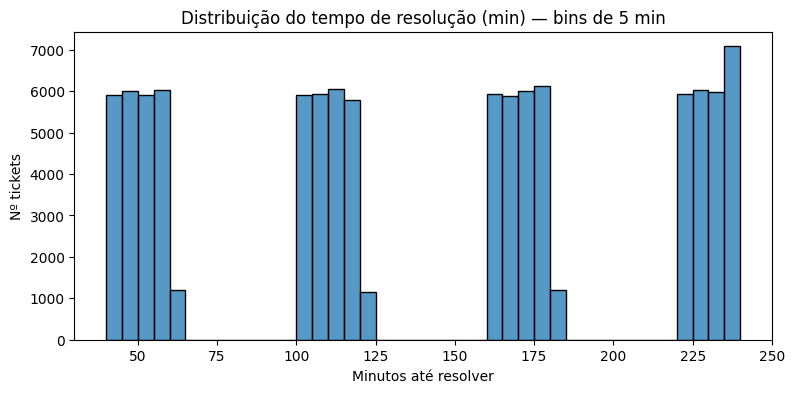

In [18]:
plt.figure(figsize=(9,4))
sns.histplot(df3["Time to resolve minutes_capped"], binwidth=5)
plt.title("Distribuição do tempo de resolução (min) — bins de 5 min")
plt.xlabel("Minutos até resolver")
plt.ylabel("Nº tickets")
plt.show()


Histograma tempo de resolução: Corresponde ao tempo de resolução a partir da hora de criaçao do ticket até a resolução do mesmo, não inclui a primeira resposta. 
O histograma sozinho não prova se o survey depende do SLA, ele mostra o comportamento do tempo de reolução, a distribuiçaõ do tempo de resolução não é contínua, aparece em patamares bem definidios ( 40-60, 100-120, 160-180 e 220-240 minutos)
Os tempos estão quantizados ( são muitos valores repetidos), possivelmente pelas regras internas de SLA, que não deixam muita liberdade aos agentes. 

Pergunta 2 Survey depende do SLA?
Tickets “Satisfied” têm tempos de SLA menores do que “Dissatisfied”?

In [19]:
sla_by_survey = (df3.groupby("Survey results")
                   .agg(
                       n=("Survey results","size"),
                       fr_mean=("First response minutes_capped","mean"),
                       res_mean=("Time to resolve minutes_capped","mean"),
                       slack_mean=("Resolution SLA slack (min)","mean"),
                   ))
display(sla_by_survey)


,n,fr_mean,res_mean,slack_mean
Survey results,,,,
Dissatisfied,33409,31.153492,139.753689,9.954473
Neutral,33345,31.275933,140.083641,10.014425
Satisfied,33246,31.341725,140.385911,9.989472


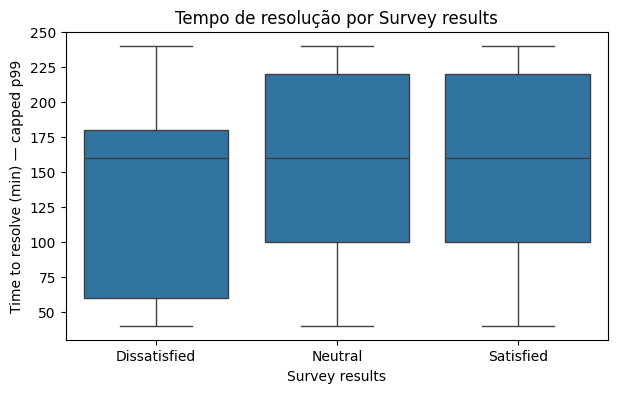

In [20]:


plt.figure(figsize=(7,4))
sns.boxplot(
    data=df3,
    x="Survey results",
    y="Time to resolve minutes_capped",
    order=["Dissatisfied","Neutral","Satisfied"]
)
plt.title("Tempo de resolução por Survey results")
plt.xlabel("Survey results")
plt.ylabel("Time to resolve (min) — capped p99")
plt.show()


Se o atendimento for acima de 100 minutos, é mais provável ter satisfeito ou neutro, se levar menos de 60 minutos será mais provável receber um resultado de survey dissatisfied. 

In [21]:
sla_by_survey = (df.groupby("Survey results")
                   .agg(
                       n=("Survey results","size"),
                       res_mean=("Time to resolve minutes_capped","mean"),
                       res_median=("Time to resolve minutes_capped","median"),
                       fr_mean=("First response minutes_capped","mean"),
                       fr_median=("First response minutes_capped","median"),
                   ))
sla_by_survey


,n,res_mean,res_median,fr_mean,fr_median
Survey results,,,,,
Dissatisfied,33409,139.753689,160.0,31.153492,35.0
Neutral,33345,140.083641,160.0,31.275933,35.0
Satisfied,33246,140.385911,160.0,31.341725,35.0


,n,dissatisfied_rate
t_bin,,
0–60,25045,0.337393
60–100,1205,0.346888
100–175,42615,0.332277
175+,31135,0.333419


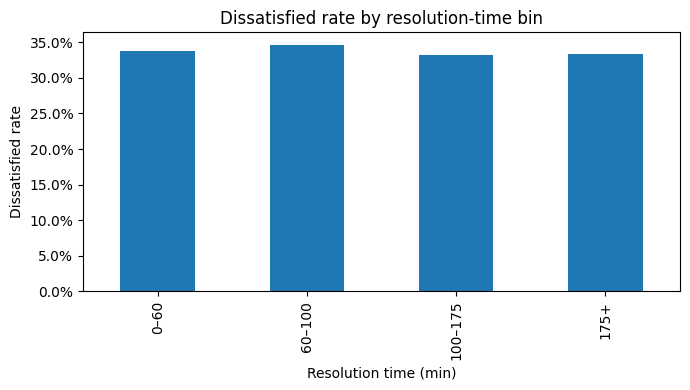

Survey results,Satisfied,Neutral,Dissatisfied
t_bin,,,
0–60,0.329886,0.332721,0.337393
60–100,0.327801,0.325311,0.346888
100–175,0.333850,0.333873,0.332277
175+,0.332809,0.333772,0.333419


In [22]:

#Configura nome da coluna 
tcol = "Time to resolve minutes_capped"  
scol = "Survey results"                  

# Manter as 3 únicas classes de surveys
df2 = df[df[scol].isin(["Satisfied", "Neutral", "Dissatisfied"])].copy()

# Flag de Satisfação diferente dos demais
df2["is_dissatisfied"] = (df2[scol] == "Dissatisfied").astype(int)

# --- Bins que testam a hipotese : pico a  60–100 nivelar ---
bins = [0, 60, 100, 175, np.inf]
labels = ["0–60", "60–100", "100–175", "175+"]

df2["t_bin"] = pd.cut(df2[tcol], bins=bins, labels=labels, include_lowest=True)  

# Rate + volume por bin
by_bin = (
    df2.groupby("t_bin", observed=True)
       .agg(n=(scol, "size"),
            dissatisfied_rate=("is_dissatisfied", "mean"))
)

display(by_bin)

# Plot o dissatisfied rate por tempo bin
ax = by_bin["dissatisfied_rate"].plot(kind="bar", figsize=(7, 4))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title("Dissatisfied rate by resolution-time bin")
plt.xlabel("Resolution time (min)")
plt.ylabel("Dissatisfied rate")
plt.tight_layout()
plt.show()

#  Ver toda a distribuição  (Satisfied/Neutral/Dissatisfied)
ct_pct = (
    pd.crosstab(df2["t_bin"], df2[scol], normalize="index")
      .reindex(columns=["Satisfied", "Neutral", "Dissatisfied"], fill_value=0)
)
display(ct_pct)


O gráfico mostra que a taxa de “Dissatisfied” é muito parecida em todos os bins de tempo de resolução (0–60, 60–100, 100–175 e 175+), ficando aproximadamente na faixa de ~33–35%.

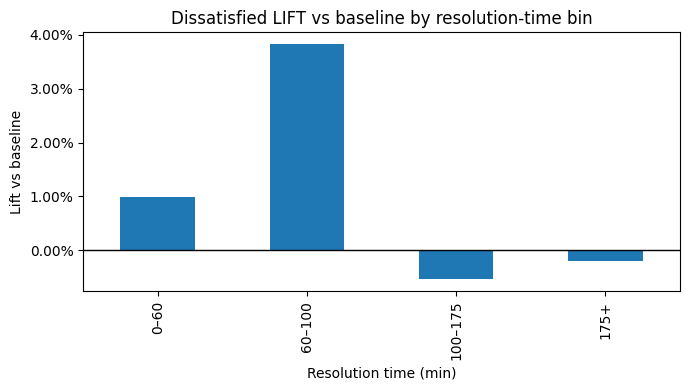

,n,rate,lift_vs_base
t_bin,,,
0–60,25045,0.337393,0.009886
60–100,1205,0.346888,0.038307
100–175,42615,0.332277,-0.005426
175+,31135,0.333419,-0.002008


In [23]:


tcol = "Time to resolve minutes_capped"
scol = "Survey results"

df2 = df[df[scol].isin(["Satisfied","Neutral","Dissatisfied"])].copy()
df2["is_dissatisfied"] = (df2[scol] == "Dissatisfied").astype(int)

bins = [0, 60, 100, 175, np.inf]
labels = ["0–60", "60–100", "100–175", "175+"]
df2["t_bin"] = pd.cut(df2[tcol], bins=bins, labels=labels, include_lowest=True)   

base = df2["is_dissatisfied"].mean()
by = df2.groupby("t_bin", observed=True).agg(n=("is_dissatisfied","size"),
                                            rate=("is_dissatisfied","mean"))
by["lift_vs_base"] = by["rate"] / base - 1  # +0.05 = 5%  mais alto que o baseline

ax = by["lift_vs_base"].plot(kind="bar", figsize=(7,4))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title("Dissatisfied LIFT vs baseline by resolution-time bin")
plt.xlabel("Resolution time (min)")
plt.ylabel("Lift vs baseline")
plt.axhline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

display(by)


Observamos um efeito não linear: a probabilidade de ‘Dissatisfied’ atinge o pico entre 60–100 min (~+4% vs baseline) e cai levemente para tempos acima de 100 min (lift negativo), sugerindo que a insatisfação está mais ligada a expectativas e tipo de atendimento do que apenas ‘demora’.

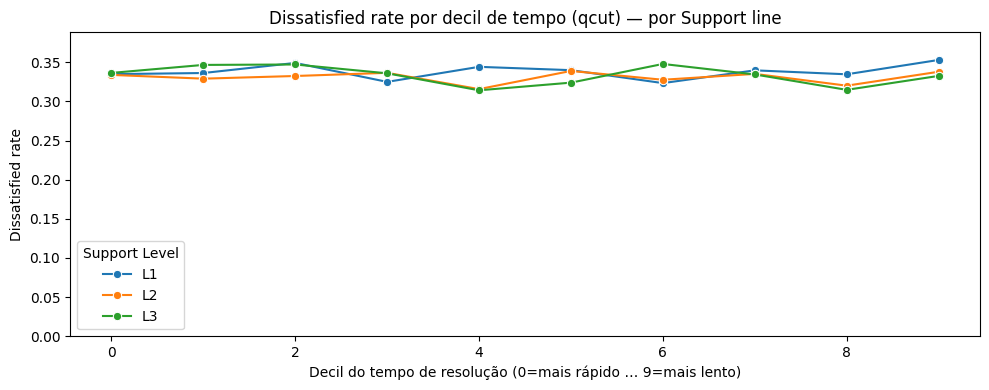

In [24]:
tcol = "Time to resolve minutes_capped"   
scol = "Survey results"
segcol = "Support Level"                   

df2 = df[df[scol].isin(["Satisfied","Neutral","Dissatisfied"])].copy()
df2["is_dissatisfied"] = (df2[scol] == "Dissatisfied").astype(int)

# Decis globais (comparáveis entre segmentos)
df2["t_decile"] = pd.qcut(df2[tcol], q=10, labels=False, duplicates="drop")  
# Taxa por decil e linha
g = (df2.groupby([segcol, "t_decile"], observed=True)
       .agg(n=("is_dissatisfied","size"),
            dis_rate=("is_dissatisfied","mean"))
       .reset_index())

#   filtrar segmentos pequenos para reduzir ruído
g = g[g["n"] >= 200]

plt.figure(figsize=(10,4))
sns.lineplot(data=g, x="t_decile", y="dis_rate", hue=segcol, marker="o")
plt.title("Dissatisfied rate por decil de tempo (qcut) — por Support line")
plt.xlabel("Decil do tempo de resolução (0=mais rápido … 9=mais lento)")
plt.ylabel("Dissatisfied rate")
plt.ylim(0, g["dis_rate"].max()*1.1)
plt.tight_layout()
plt.show()

As três linhas (L1, L2 e L3) são muito próximas entre si em praticamente todos os decis, o que sugere que o nível de suporte não altera fortemente a relação entre tempo de resolução e insatisfação (não há separação clara entre L1/L2/L3).

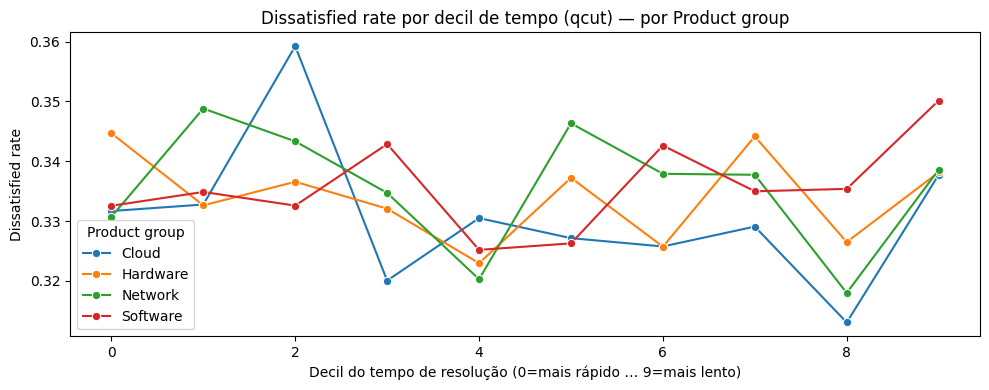

In [25]:
segcol = "Product group"   

g = (df2.groupby([segcol, "t_decile"], observed=True)
       .agg(n=("is_dissatisfied","size"),
            dis_rate=("is_dissatisfied","mean"))
       .reset_index())

g = g[g["n"] >= 200]

plt.figure(figsize=(10,4))
sns.lineplot(data=g, x="t_decile", y="dis_rate", hue=segcol, marker="o")
plt.title("Dissatisfied rate por decil de tempo (qcut) — por Product group")
plt.xlabel("Decil do tempo de resolução (0=mais rápido … 9=mais lento)")
plt.ylabel("Dissatisfied rate")
plt.tight_layout()
plt.show()


Quando segmentamos por Product group, o efeito do tempo deixa de ser plano: Cloud mostra um pico de Dissatisfied em um decil relativamente rápido (decil 2),
enquanto Software piora no decil mais lento (9). 
Isso indica que a insatisfação não depende só do tempo, mas do tipo de caso e expectativa do cliente em cada grupo.
 

In [26]:
g.sort_values("dis_rate", ascending=False).head(10)


,Product group,t_decile,n,dis_rate
2,Cloud,2,2714,0.359248
39,Software,9,2339,0.350150
21,Network,1,2368,0.348818
25,Network,5,2356,0.346350
10,Hardware,0,2791,0.344679
17,Hardware,7,2711,0.344153
22,Network,2,2700,0.343333
33,Software,3,2374,0.342881
36,Software,6,2402,0.342631
29,Network,9,2351,0.338579


Quando segmentamos por Product group e decis de tempo, surgem pockets com maior Dissatisfied: Cloud no decil 2 (~35.9%) e Software no decil 9 (~35.0%). Isso indica que o driver de insatisfação é mais dependente do tipo de caso e do contexto do atendimento do que apenas ‘mais tempo = pior

Resposta/Interpretação: Comparando o tempo de resolução (capped p99) entre Dissatisfied, Neutral e Satisfied, as medianas parecem muito próximas e há grande sobreposição entre as caixas (IQR). Isto indica que, neste dataset, o tempo de resolução por si só não separa bem as avaliações — a satisfação pode depender mais de outros fatores (ex.: dia da semana, tópico, prioridade, expectativa do utilizador) ou de uma combinação de variáveis.

In [27]:
#Para cada tipo de avaliação, quantos tickets existem e quais são os tempos médios/medianos de SLA

sla_by_survey = (df.groupby("Survey results")
                   .agg(
                       n=("Survey results","size"),
                       fr_mean=("First response minutes_capped","mean"),
                       fr_median=("First response minutes_capped","median"),
                       res_mean=("Time to resolve minutes_capped","mean"),
                       res_median=("Time to resolve minutes_capped","median"),
                       slack_mean=("Resolution SLA slack (min)","mean"),
                   ))
display(sla_by_survey)


,n,fr_mean,fr_median,res_mean,res_median,slack_mean
Survey results,,,,,,
Dissatisfied,33409,31.153492,35.0,139.753689,160.0,9.954473
Neutral,33345,31.275933,35.0,140.083641,160.0,10.014425
Satisfied,33246,31.341725,35.0,140.385911,160.0,9.989472


Comparando o tempo de resolução (capped p99) entre Dissatisfied, Neutral e Satisfied, as medianas são muito próximas e há grande sobreposição do IQR, indicando que, no agregado, a duração não separa bem as avaliações. Contudo, ao analisar lift vs baseline e segmentar por decis (qcut), surge um padrão não linear: a taxa de Dissatisfied aumenta em faixas intermediárias (ex.: 60–100 min) e diminui ligeiramente em tempos mais altos. Esse efeito fica mais evidente por Product group, com picos específicos (ex.: Cloud no decil 2 e Software no decil 9), sugerindo que a satisfação depende de uma combinação de variáveis (case mix/expectativa) e não apenas do tempo.


,Created_dow,n,neg_rate
0,0,14293,0.330511
1,1,14482,0.329927
2,2,14164,0.335145
3,3,14152,0.331473
4,4,14288,0.334686
5,5,14371,0.334284
6,6,14250,0.342667


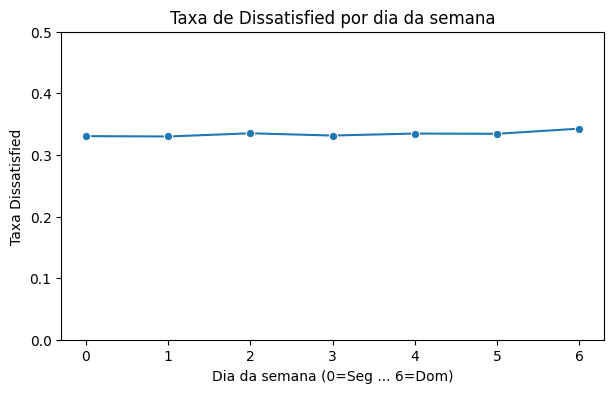

In [28]:
#Rate por dia da semana
dow = (df.assign(is_neg=(df["Survey results"] == "Dissatisfied").astype(int))
         .groupby("Created_dow")
         .agg(n=("Created_dow","size"), neg_rate=("is_neg","mean"))
         .reset_index())

display(dow)

plt.figure(figsize=(7,4))
sns.lineplot(data=dow, x="Created_dow", y="neg_rate", marker="o")
plt.title("Taxa de Dissatisfied por dia da semana")
plt.xlabel("Dia da semana (0=Seg ... 6=Dom)")
plt.ylabel("Taxa Dissatisfied")
plt.ylim(0,0.5)
plt.show()


O domingo tem maior taxa de Dissatisfied?

Interpretação: A taxa de tickets com avaliação Dissatisfied varia com o dia da semana. Observa‑se um aumento claro no domingo (Created_dow = 6), que apresenta a maior taxa de insatisfação (aprox. 0,343), enquanto nos outros dias a taxa fica mais próxima de ~0,330–0,335. Isto sugere que tickets criados ao domingo têm maior probabilidade de receber avaliação negativa, possivelmente por menor disponibilidade de recursos, tempos de resposta diferentes ou complexidade/urgência diferente dos pedidos.

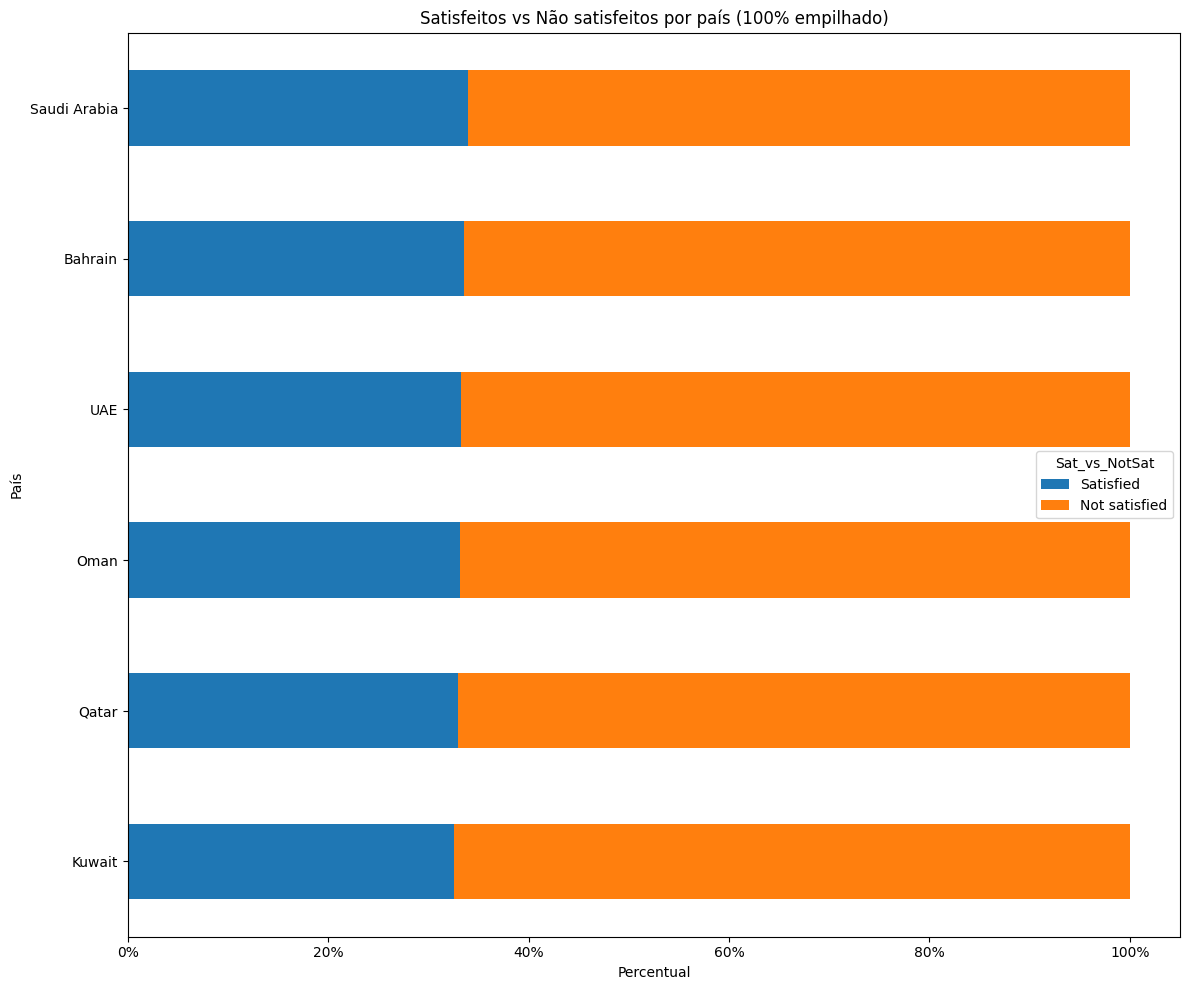

In [29]:
# Gráfico binário por país (100% empilhado) 


country_col = "Country"      
scol = "Survey results"

df2 = df[df[scol].isin(["Satisfied","Neutral","Dissatisfied"])].copy()
df2["Sat_vs_NotSat"] = df2[scol].replace({
    "Satisfied": "Satisfied",
    "Neutral": "Not satisfied",
    "Dissatisfied": "Not satisfied"
})

ct = pd.crosstab(df2[country_col], df2["Sat_vs_NotSat"], normalize="index")  
ct = ct.reindex(columns=["Satisfied","Not satisfied"], fill_value=0).sort_values("Not satisfied", ascending=False)

ax = ct.plot(kind="barh", stacked=True, figsize=(12, 10))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title("Satisfeitos vs Não satisfeitos por país (100% empilhado)")
plt.xlabel("Percentual")
plt.ylabel("País")
plt.tight_layout()
plt.show()


Quando agregamos Neutral e Dissatisfied como ‘Not satisfied’, observamos que a não satisfação é maioritária em todos os países analisados, com variação pequena entre eles; isso sugere que o fenómeno é mais global do que específico de um único país.


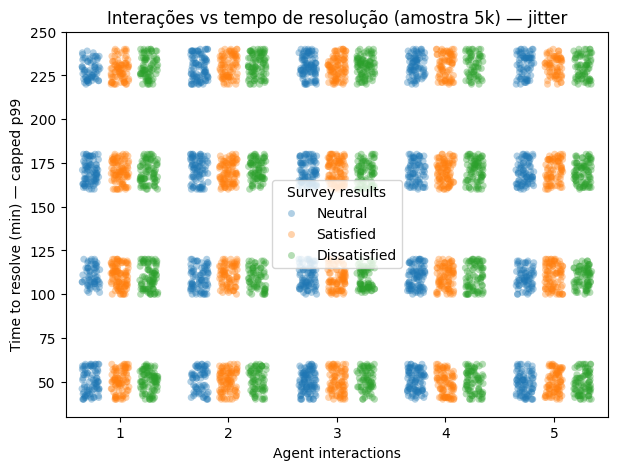

In [30]:


plt.figure(figsize=(7,5))
sns.stripplot(
    data=df.sample(5000, random_state=42),
    x="Agent interactions",
    y="Time to resolve minutes_capped",
    hue="Survey results",
    jitter=0.25,
    dodge=True,
    alpha=0.35
)
plt.title("Interações vs tempo de resolução (amostra 5k) — jitter")
plt.xlabel("Agent interactions")
plt.ylabel("Time to resolve (min) — capped p99")
plt.legend(title="Survey results")
plt.show()


As três cores estão muito misturadas em praticamente todos os níveis de interações e tempos, então (interações, tempo) por si só não separa bem Satisfied/Neutral/Dissatisfied.

Os pontos formam bandas horizontais (patamares de tempo), o que sugere valores discretizados/arredondados e/ou efeito do “capped p99”; isso pode reduzir correlações lineares e favorecer modelos que capturam interações/não linearidade.

A ausência de clusters claros reforça a hipótese de que a satisfação depende de mais variáveis (ex.: Product group, país, SLA, prioridade) e de combinações.

Machine Learning 

Definição do problema
O objetivo é prever a probabilidade de um ticket gerar uma avaliação negativa no survey. Formulei o problema como classificação binária, onde o target é NotSatisfied (1 se Survey results ∈ {Neutral, Dissatisfied} e 0 se Survey results = Satisfied).

Preparação dos dados
Separei as features (X) e o target (y) e fiz train_test_split 80/20 com stratify=y. Para o pré-processamento, usei um pipeline com ColumnTransformer: features numéricas foram imputadas (mediana) e escaladas (StandardScaler), e features categóricas foram imputadas (moda) e codificadas com OneHotEncoder.




 ======== LogReg ========
              precision    recall  f1-score   support

           0      0.000     0.000     0.000      6649
           1      0.668     1.000     0.801     13351

    accuracy                          0.668     20000
   macro avg      0.334     0.500     0.400     20000
weighted avg      0.446     0.668     0.534     20000



c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

<Figure size 450x400 with 0 Axes>

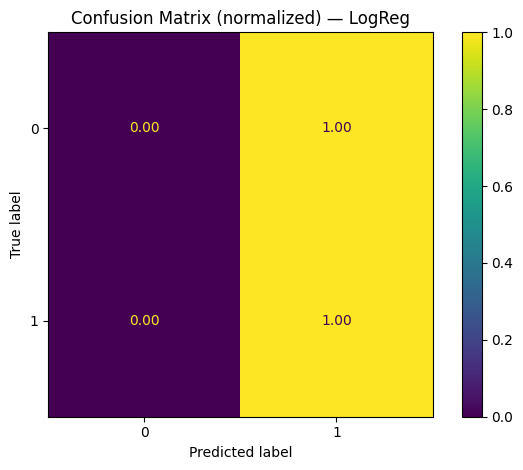


 ======== RandomForest ========
              precision    recall  f1-score   support

           0      0.324     0.254     0.285      6649
           1      0.665     0.737     0.699     13351

    accuracy                          0.576     20000
   macro avg      0.494     0.495     0.492     20000
weighted avg      0.551     0.576     0.561     20000



<Figure size 450x400 with 0 Axes>

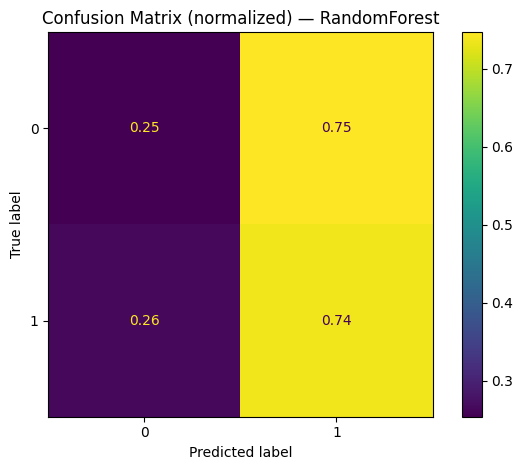

,model,accuracy,precision,recall,f1
0,LogReg,0.66755,0.667550,1.000000,0.800636
1,RandomForest,0.57605,0.664617,0.736649,0.698781


In [31]:
 

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# -------------------------
# 1) Define problema
# -------------------------
scol = "Survey results"
df_ml = df[df[scol].isin(["Satisfied", "Neutral", "Dissatisfied"])].copy()

df_ml["NotSatisfied"] = df_ml[scol].isin(["Neutral", "Dissatisfied"]).astype(int)
y = df_ml["NotSatisfied"]

# -------------------------
# 2) Escolhe  
# -------------------------
features = [
    "Time to resolve minutes_capped",
    "Agent interactions",
    "Country",
    "Product group",
    "Support Level",
  
]
X = df_ml[features].copy()

# Detecta numérico e categórico automaticamente
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

# -------------------------
# 3) Processo
# -------------------------
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)  

# -------------------------
# 4) Split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------
# 5) Treino 2 modelos
# -------------------------
models = {
    "LogReg": LogisticRegression(max_iter=2000),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
}

results = []

for name, clf in models.items():
    pipe = Pipeline(steps=[("prep", preprocess), ("model", clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),  # Precisão harmónica
    })

    print("\n", "="*8, name, "="*8)
    print(classification_report(y_test, y_pred, digits=3))

    plt.figure(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, normalize="true", values_format=".2f"
    )  # [web:662]
    plt.title(f"Confusion Matrix (normalized) — {name}")
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results).sort_values("f1", ascending=False)
display(results_df)


Modelos treinados
Treinei dois modelos de classificação:

Logistic Regression (baseline interpretável).

O modelo Logistic Regression apresentou accuracy = 0.668, mas isso acontece porque ele praticamente prevê sempre a classe 1 (NotSatisfied). Como consequência, ele obteve recall = 1.00 para a classe 1 (captura todos os NotSatisfied), mas teve precision/recall/F1 = 0.00 para a classe 0 (Satisfied), ou seja, não consegue identificar tickets satisfeitos.
Conclusão: apesar da accuracy razoável, o modelo é pouco útil para diferenciar as classes, pois age como um “baseline” que marca quase tudo como NotSatisfied.

Random Forest Classifier (modelo não linear para capturar interações e padrões complexos).

Accuracy = 0.576, mas melhora muito em “equilíbrio”: macro avg f1 = 0.492 e F1(0) = 0.285, ou seja, já consegue reconhecer alguns Satisfied

O modelo é útil? Que limitações tem?
O modelo é parcialmente útil se o foco for priorizar risco de NotSatisfied (classe 1), porque ambos têm desempenho razoável para essa classe, mas a LogReg faz isso de um jeito “trivial” (prevê quase tudo como 1). A principal limitação é que a classe 0 (Satisfied) está com desempenho fraco (especialmente na LogReg, que não detecta nenhum caso), o que indica desbalanceamento e/ou features com pouco sinal para separar as classes; na prática, isso gera muitos erros ao tentar identificar satisfeitos e pode inflar a accuracy. Melhorias típicas: usar class_weight="balanced", ajustar o threshold (não ficar preso em 0.5), otimizar métrica alvo (ex.: F1-macro ou recall da classe 0/1 conforme o objetivo) e validar com PR-AUC/ROC-AUC e matriz de confusão.



### Considerações finais (projeto concluído)

Neste projeto, foi realizada uma análise exploratória e construída uma pipeline de **Machine Learning** para prever a variável alvo binária `NotSatisfied` (0 = Satisfied, 1 = NotSatisfied) a partir das features disponíveis. O problema foi modelado como **classificação supervisionada**, com divisão treino/teste e avaliação por métricas por classe (precision, recall e F1-score), além de métricas agregadas (accuracy, macro avg e weighted avg). Os dados apresentaram **desbalanceamento** relevante no conjunto de teste (classe 0 com 6.649 instâncias vs classe 1 com 13.351), o que condicionou tanto o treino quanto a interpretação dos resultados.

Foram treinados dois modelos: **Logistic Regression** como baseline interpretável e **Random Forest Classifier** como alternativa não linear. A Logistic Regression obteve `accuracy ≈ 0.668` e `F1(1) ≈ 0.801`, mas apresentou `F1(0) = 0.000`, evidenciando que o modelo praticamente colapsou para a previsão da classe majoritária (`NotSatisfied`). Apesar do valor de accuracy, esse comportamento indica baixa capacidade discriminativa para a classe `Satisfied`, tornando o modelo inadequado quando o objetivo é diferenciar de forma confiável as duas classes. Já o Random Forest apresentou menor `accuracy ≈ 0.576`, porém conseguiu prever ambas as classes (`F1(0) ≈ 0.285`, `macro avg F1 ≈ 0.492`, `F1(1) ≈ 0.699`), caracterizando um desempenho mais equilibrado, ainda que com limitações.

Um aspeto relevante e, em certa medida, **surpreendente**, foi a discrepância entre métricas globais e desempenho por classe: a Logistic Regression aparentou boa performance quando observada apenas pela accuracy, mas falhou completamente em recuperar a classe 0. Este resultado reforça a necessidade de avaliar modelos em cenários desbalanceados com métricas sensíveis a ambas as classes (ex.: macro-F1 e análise por classe) e não apenas com accuracy, que pode mascarar modelos “triviais”. Além disso, ao nível da análise de dados, a perceção de que a base é “uniforme” (pouca variabilidade/baixo sinal) é coerente com a dificuldade dos modelos em separar as classes: quando as features não capturam os principais determinantes do target, a capacidade preditiva tende a ser limitada e pouco acionável.

Quanto à utilidade prática, o modelo, na forma atual, é **limitadamente útil** para recomendações de negócio. A Logistic Regression não é apropriada para uso operacional por não identificar casos `Satisfied`. O Random Forest pode ter algum valor como triagem grosseira (priorização de risco para `NotSatisfied`), mas o baixo desempenho na classe `Satisfied` e a ausência de explicabilidade/driver analysis consistente reduzem a utilidade para orientar decisões estratégicas (isto é, “o que mudar no processo para aumentar satisfação”). Assim, o projeto conclui que, com as features disponíveis e sem engenharia adicional, o ML não fornece evidência robusta para recomendações fortes.

Como próximos passos (caso houvesse mais tempo) (1) **mitigação do desbalanceamento** (ex.: `class_weight`, ajuste de threshold e otimização por macro-F1 ou por custo de erro), (2) introdução de **features mais informativas e acionáveis** (ex.: tempo até primeira resposta, violações de SLA, número de interações, reaberturas, tempo total, categoria/tema do ticket, carga do time no momento), (3) revisão de **qualidade e granularidade** do target (possível ruído e fatores externos à base), e (4) inclusão de uma etapa formal de **explicabilidade** (importância por permutação/SHAP) para apoiar interpretação e recomendações. Em paralelo, para gerar insights de negócio mesmo com baixo sinal preditivo, seria adequado complementar com análises segmentadas (por canal, categoria, time, prioridade) e hipóteses testáveis para melhoria de processo.

 